# **Pemrosesan Data Teks (Working with Text Data)**
Catatan ini menguraikan metodologi komputasi untuk mentransformasi data teks tak terstruktur menjadi representasi numerik yang dapat diproses oleh algoritma machine learning. Fokus utama pembahasan mencakup teknik ekstraksi fitur dasar seperti Bag-of-Words (BoW) dan pembobotan Term Frequency-Inverse Document Frequency (TF-IDF), optimasi fitur melalui penghapusan stopwords dan N-grams, serta penerapannya dalam analisis sentimen.

## **Tujuan Pembelajaran**
Karakterisasi Teks: Memahami sifat fundamental data teks dan membedakannya dari tipe data string lainnya.

Transformasi Numerik: Menguasai konversi teks menjadi vektor angka menggunakan CountVectorizer dan memahami konsep sparse matrix.

Reduksi Dimensi Fitur: Menerapkan parameter min_df dan stopwords untuk mengeliminasi fitur tekstual yang tidak informatif (derau/ noise).

Pembobotan Lanjutan: Menggunakan TfidfVectorizer untuk memberikan bobot proporsional pada kata berdasarkan tingkat signifikansinya dalam sebuah korpus.

Konteks Sekuensial: Memahami dan menerapkan ekspansi fitur n-grams untuk menangkap konteks frasa.

Integrasi Pipeline: Membangun alur kerja klasifikasi teks dan menginterpretasikan koefisien model untuk analisis prediktif.

# **Bagian 1: Persiapan Lingkungan Kerja (Environment Setup)**
Modul ini menggunakan pustaka standar komputasi saintifik dan memuat dataset teks buatan (toy dataset) secara internal agar eksperimen dapat direproduksi tanpa ketergantungan pada berkas eksternal.

In [49]:
# Memuat pustaka komputasi dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memuat modul ekstraksi fitur teks scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS

# Memuat modul pemodelan dan evaluasi
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Konfigurasi parameter dasar
np.random.seed(42)
pd.set_option("display.max_columns", 100)

# **Bagian 2: Tipologi Data String & Definisi Dataset**
Algoritma machine learning tidak dapat menelan teks mentah secara langsung karena panjangnya yang bervariasi dan ketiadaan nilai matematis bawaan. Sebelum melakukan prapemrosesan, kita harus mengklasifikasikan jenis data string yang sedang ditangani,

In [50]:
# Pembuatan Toy Dataset Ulasan Film
texts = [
    "film ini sangat bagus dan ceritanya menyenangkan",
    "akting pemainnya luar biasa dan filmnya sangat menarik",
    "saya suka film ini karena alurnya bagus",
    "cerita film ini menyentuh dan endingnya memuaskan",
    "film yang hebat dengan visual yang indah",
    "pengalaman menonton yang sangat menyenangkan",
    "film ini buruk dan sangat membosankan",
    "ceritanya jelek dan aktingnya kaku",
    "saya tidak suka film ini karena alurnya membingungkan",
    "film ini terlalu panjang dan membosankan",
    "endingnya buruk dan tidak memuaskan",
    "film ini gagal membuat saya tertarik",
    "visualnya bagus tetapi ceritanya buruk",
    "aktingnya bagus namun alurnya membosankan",
    "film ini cukup menarik dan punya pesan bagus",
    "ceritanya buruk tetapi beberapa adegan cukup bagus"
]

labels = np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

data = pd.DataFrame({"text": texts, "sentiment": labels})
display(data.head())

,text,sentiment
0,film ini sangat bagus dan ceritanya menyenangkan,1
1,akting pemainnya luar biasa dan filmnya sangat...,1
2,saya suka film ini karena alurnya bagus,1
3,cerita film ini menyentuh dan endingnya memuaskan,1
4,film yang hebat dengan visual yang indah,1


# **Bagian 3: Representasi Bag-of-Words (BoW)**
Bag-of-words adalah paradigma ekstraksi fitur yang paling fundamental. Representasi ini mengabaikan struktur sintaksis dan urutan kata, serta murni berfokus pada frekuensi kemunculan setiap kata dalam dokumen. Proses ini terdiri dari tiga tahap:

1. Tokenisasi (Tokenization): Memecah kalimat menjadi unit terkecil (token/kata).

2. Pembangunan Kosakata (Vocabulary Building): Menghimpun daftar seluruh kata unik dari keseluruhan korpus dokumen.

3. Penyandian (Encoding): Menghitung frekuensi absolut setiap kata unik per dokumen.

In [51]:
# Demonstrasi CountVectorizer pada dua kalimat pendek
toy_texts = [
    "The fool doth think he is wise",
    "but the wise man knows himself to be a fool"
]

vect = CountVectorizer()
vect.fit(toy_texts)

print("Kapasitas Kosakata (Vocabulary):", len(vect.vocabulary_))

# Ekstraksi ke dalam Sparse Matrix (Matriks Jarang)
bag_of_words = vect.transform(toy_texts)
print("\nRepresentasi Sparse Matrix:\n", bag_of_words)

# Konversi ke Dense Matrix untuk inspeksi visual
display(pd.DataFrame(bag_of_words.toarray(), columns=vect.get_feature_names_out()))

Kapasitas Kosakata (Vocabulary): 13

Representasi Sparse Matrix:
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>
  Coords	Values
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 6)	1
  (0, 9)	1
  (0, 10)	1
  (0, 12)	1
  (1, 0)	1
  (1, 1)	1
  (1, 3)	1
  (1, 5)	1
  (1, 7)	1
  (1, 8)	1
  (1, 9)	1
  (1, 11)	1
  (1, 12)	1


,be,but,doth,fool,he,himself,is,knows,man,the,think,to,wise
0,0,0,1,1,1,0,1,0,0,1,1,0,1
1,1,1,0,1,0,1,0,1,1,1,0,1,1


# **Bagian 4: Pemodelan Berbasis Teks dan Pipeline**
Setelah dikonversi menjadi fitur numerik (BoW), kita dapat melatih model klasifikasi. Untuk ruang fitur berdimensi tinggi yang sparse, model linear seperti Logistic Regression atau Support Vector Machines (SVM) sangat direkomendasikan karena kecenderungan tahannya terhadap overfitting spasial.

In [52]:
# Pemisahan himpunan data
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["text"], data["sentiment"], test_size=0.3,
    random_state=42, stratify=data["sentiment"]
)

# Integrasi Vektorisasi dan Model menggunakan Pipeline
pipe_count = make_pipeline(CountVectorizer(), LogisticRegression(max_iter=1000))

# Evaluasi menggunakan Cross-Validation
scores = cross_val_score(pipe_count, data["text"], data["sentiment"], cv=4)
print(f"Skor Akurasi Validasi Silang (Cross-Validation): {scores.mean():.2f}")

Skor Akurasi Validasi Silang (Cross-Validation): 0.69


# **Bagian 5: Reduksi Dimensi Fitur (min_df dan Stopwords)**
Korpus berskala besar sering kali mengandung dua jenis anomali: kata yang teramat sangat jarang muncul (misal: typo spesifik) dan kata yang terlalu sering muncul namun nir-makna gramatikal (misal: konjungsi atau preposisi).

- min_df (Minimum Document Frequency): Mengeliminasi kata yang kemunculannya tidak memenuhi ambang batas minimal dokumen.

- Stopwords: Mengeliminasi kata fungsional standar bahasa yang tidak membawa informasi prediktif spesifik domain.

In [53]:
# 1. Implementasi ambang batas min_df
vect_min1 = CountVectorizer(min_df=1).fit_transform(data["text"])
vect_min2 = CountVectorizer(min_df=2).fit_transform(data["text"])

print(f"Total dimensi fitur dengan min_df=1: {vect_min1.shape[1]}")
print(f"Total dimensi fitur dengan min_df=2: {vect_min2.shape[1]}")

# 2. Implementasi Stopwords Bahasa Indonesia Kustom
indonesian_stopwords = ["dan", "yang", "di", "ini", "itu", "saya", "karena", "dengan", "sangat", "tetapi", "namun"]

vect_stop = CountVectorizer(stop_words=indonesian_stopwords)
X_stop = vect_stop.fit_transform(data["text"])
print(f"\nTotal dimensi fitur pasca-penghapusan stopwords: {X_stop.shape[1]}")

Total dimensi fitur dengan min_df=1: 48
Total dimensi fitur dengan min_df=2: 21

Total dimensi fitur pasca-penghapusan stopwords: 39


# **Bagian 6: Pembobotan TF-IDF (Term Frequency-Inverse Document Frequency)**
Berlawanan dengan kalkulasi absolut dari metode BoW, TF-IDF memberikan penalti bobot pada kata yang repetitif di hampir seluruh korpus dokumen.

- Prinsip Kerja: Jika sebuah kata sering muncul dalam satu dokumen tertentu, namun jarang muncul di dokumen-dokumen lain, kata tersebut diasumsikan sebagai kata kunci (informasi sentral) dari dokumen tersebut dan diberikan bobot maksimal.

In [54]:
# Implementasi Transformasi TF-IDF
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(data["text"])

# Visualisasi Bobot Fitur TF-IDF
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
display(tfidf_df.head(3))

# Pipeline Model berbasis TF-IDF terintegrasi dengan GridSearchCV
pipe_tfidf = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))

param_grid = {
    "tfidfvectorizer__min_df": [1, 2],
    "tfidfvectorizer__ngram_range": [(1, 1), (1, 2)],
    "logisticregression__C": [0.1, 1, 10]
}

grid = GridSearchCV(pipe_tfidf, param_grid, cv=4)
grid.fit(data["text"], data["sentiment"])

print("Parameter Ekstraksi & Model Terbaik:", grid.best_params_)
print(f"Skor CV Terbaik: {grid.best_score_:.3f}")

,adegan,akting,aktingnya,alurnya,bagus,beberapa,biasa,buruk,cerita,ceritanya,cukup,dan,dengan,endingnya,film,filmnya,gagal,hebat,indah,ini,jelek,kaku,karena,luar,membingungkan,membosankan,membuat,memuaskan,menarik,menonton,menyenangkan,menyentuh,namun,panjang,pemainnya,pengalaman,pesan,punya,sangat,saya,suka,terlalu,tertarik,tetapi,tidak,visual,visualnya,yang
0,0.0,0.000000,0.0,0.000000,0.352745,0.0,0.000000,0.0,0.0,0.415633,0.0,0.305773,0.0,0.0,0.286081,0.000000,0.0,0.0,0.0,0.305773,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.511109,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.415633,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.391288,0.0,0.000000,0.000000,0.0,0.391288,0.0,0.0,0.000000,0.0,0.203863,0.0,0.0,0.000000,0.391288,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.391288,0.0,0.0,0.0,0.0,0.340763,0.0,0.000000,0.0,0.0,0.0,0.391288,0.0,0.0,0.0,0.277108,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.410612,0.316704,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.256851,0.000000,0.0,0.0,0.0,0.274531,0.0,0.0,0.458887,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.410612,0.458887,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Parameter Ekstraksi & Model Terbaik: {'logisticregression__C': 10, 'tfidfvectorizer__min_df': 1, 'tfidfvectorizer__ngram_range': (1, 1)}
Skor CV Terbaik: 0.688


# **Bagian 7: Ekstraksi Konteks via N-Grams**
Metode CountVectorizer standar bersifat unigram (memutus teks menjadi kata tunggal). Kerugiannya, konteks relasional antar-kata akan lenyap (misal: "tidak bagus" akan dipecah menjadi "tidak" dan "bagus", memutarbalikkan sentimen aslinya). N-grams menyelesaikan masalah ini dengan merekam rangkaian kombinasi kata yang berurutan.

In [55]:
# Demonstrasi perluasan konteks vektorisasi
example_texts = ["film ini tidak bagus", "film ini sangat bagus"]

# Menampilkan hasil komparasi parameter ngram_range
for ngram in [(1, 1), (2, 2), (1, 2)]:
    cv = CountVectorizer(ngram_range=ngram)
    X_ngram = cv.fit_transform(example_texts)
    print(f"\nParameter N-Gram Range: {ngram}")
    print("Daftar Fitur Ekstraksi:", cv.get_feature_names_out())


Parameter N-Gram Range: (1, 1)
Daftar Fitur Ekstraksi: ['bagus' 'film' 'ini' 'sangat' 'tidak']

Parameter N-Gram Range: (2, 2)
Daftar Fitur Ekstraksi: ['film ini' 'ini sangat' 'ini tidak' 'sangat bagus' 'tidak bagus']

Parameter N-Gram Range: (1, 2)
Daftar Fitur Ekstraksi: ['bagus' 'film' 'film ini' 'ini' 'ini sangat' 'ini tidak' 'sangat'
 'sangat bagus' 'tidak' 'tidak bagus']


# **Bagian 8: Interpretabilitas Model (Model Interrogability)**
Salah satu keunggulan utama dari perpaduan model linear dan representasi teks vektor (khususnya Logistic Regression) adalah transparansi interpretasinya. Kita dapat memetakan koefisien regresor secara langsung kembali ke matriks kosakata untuk menganalisis kata mana yang paling berpengaruh secara positif maupun negatif.

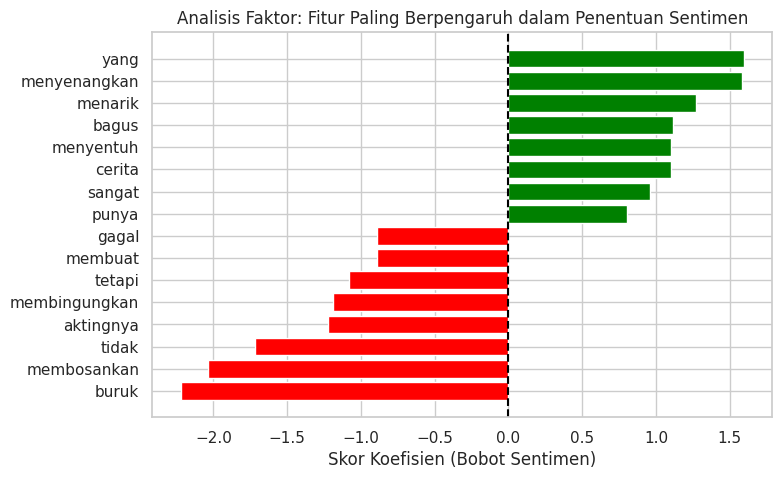

In [56]:
# Mengekstrak bobot koefisien dari estimator terbaik (GridSearch)
best_model = grid.best_estimator_
vectorizer = best_model.named_steps["tfidfvectorizer"]
classifier = best_model.named_steps["logisticregression"]

# Memetakan nilai koefisien ke nama fitur (kata/N-gram)
coef_df = pd.DataFrame({
    "feature": np.array(vectorizer.get_feature_names_out()),
    "coefficient": classifier.coef_[0]
}).sort_values("coefficient")

# Ekstraksi fitur paling ekstrem (Negatif vs Positif)
top_negative = coef_df.head(8)
top_positive = coef_df.tail(8)
plot_df = pd.concat([top_negative, top_positive])

# Visualisasi Pengaruh Fitur terhadap Keputusan Model
plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["coefficient"], color=['red']*8 + ['green']*8)
plt.xlabel("Skor Koefisien (Bobot Sentimen)")
plt.title("Analisis Faktor: Fitur Paling Berpengaruh dalam Penentuan Sentimen")
plt.axvline(0, linestyle="--", color='black')
plt.show()